In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path('.').resolve().parent / 'src'))
from narrativa import estilo, capitulo, mapa, nota, descartes, kpis, frase
estilo()
capitulo(3, 'Seis preguntas de negocio, seis gráficos',
         'Cada gráfico existe porque responde algo que el Gerente de Contenidos necesita decidir. El que no respondía nada, no quedó.',
         ceja='Notebook 03 de 04 · Análisis exploratorio')

In [2]:
mapa(['Auditoría de datos', 'Limpieza e integración', 'Análisis exploratorio', 'Informe narrativo'], 3)

# 03 — Análisis exploratorio
StreamView Analytics · ADY1104 · Matías Retamal · Claudio González

Seis visuales, uno por pregunta del Gerente de Contenidos. Cada gráfico se guarda en `images/exploratorio/` y tiene su entrada en `docs/decisiones_diseno.md` escrita en el mismo momento en que se creó.

| # | Pregunta del Gerente | Visual |
|---|---|---|
| 16 | ¿Qué géneros priorizar? | Nota ponderada por género (películas) |
| 17 | ¿Qué países priorizar? | Nota ponderada por país de origen |
| 18 | ¿Dónde el gasto se traduce en retorno? | ROI por nota y por presupuesto |
| 19 | ¿Dónde hay una oportunidad que hoy no veo? | Volumen contra nota, por género |
| 20 | ¿Conviene película o serie? | Nota por tipo en los géneros comunes |
| 21 | ¿Cuál de esas oportunidades además paga? | Nota contra ROI, por género |

Ninguna agregación se calcula dentro del notebook: todas vienen de `src/analisis.py`, y todo el estilo de `src/graficos.py`. El notebook arma la narración; los módulos hacen el trabajo y quedan auditables por separado.

In [3]:
import sys
from pathlib import Path

sys.path.append(str(Path('.').resolve().parent / 'src'))
import matplotlib.pyplot as plt
from graficos import *
from analisis import *
from etiquetas import GENEROS, PAISES, traducir

aplicar_estilo()
cat, largos = cargar_procesado()
n2 = lambda v: num_es(v, 2)

## 16 · ¿Qué géneros priorizar?

Dos medidas por categoría — cuánto hay y qué tan bien recibido está — pero **un solo eje**: la nota. El volumen va como columna de texto a la derecha, no como segundo eje. Un gráfico de doble eje deja que la escala elegida decida qué serie va "arriba", y eso es una conclusión regalada por el diseño y no por los datos.

Es un **dot plot y no barras** porque el rango útil de notas es estrecho (5,89 a 7,01). La longitud de una barra codifica magnitud desde cero; con este rango, o se trunca el eje —que está prohibido— o todas las barras se ven iguales. El punto codifica por posición y no necesita origen en cero.

El análisis es **solo de películas**: los dos tipos usan taxonomías de género distintas y mezclarlos compararía dos vocabularios.

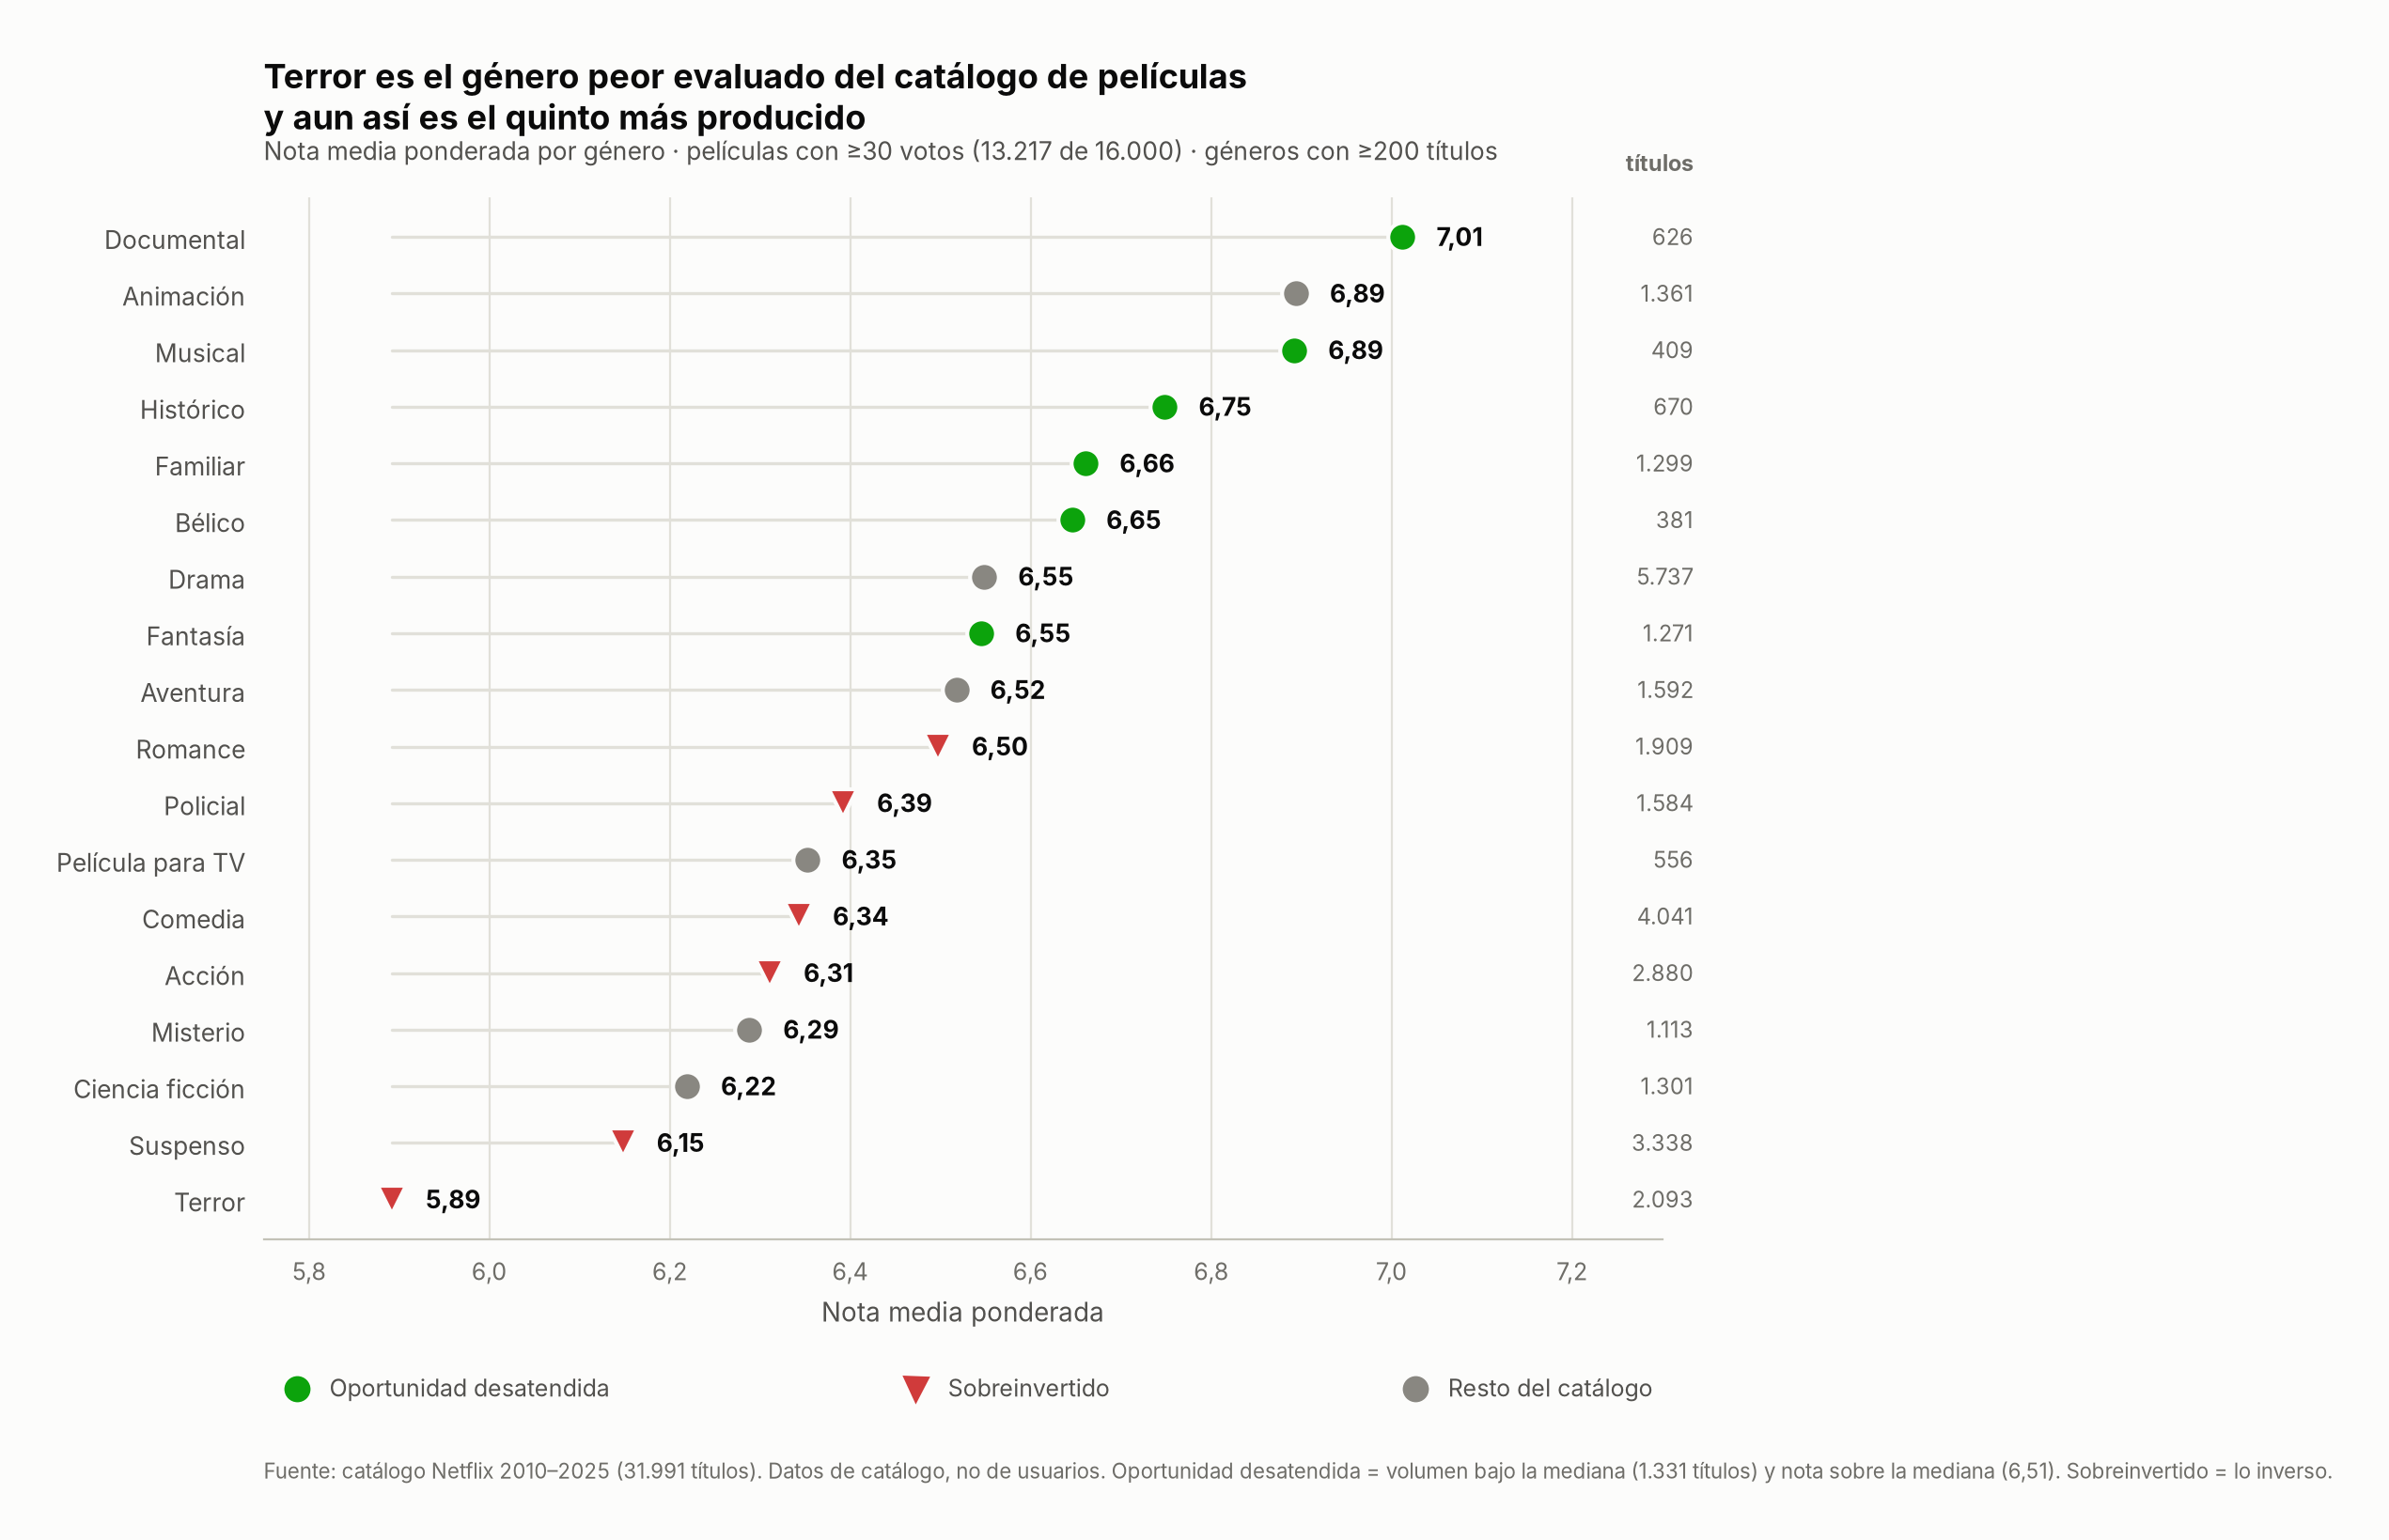

PosixPath('/home/user/Visualizaci-n_datos/images/exploratorio/16_genero_nota_peliculas.png')

In [4]:
res = clasificar_brecha(desempeno_por_dimension(largos['genero'], cat, 'genero', tipo='Película'))
r = res.sort_values('nota')
fig, ax = plt.subplots(figsize=(9.6, 7.2))
col = [ACENTO[s] if s in ('oportunidad','sobreinvertido') else ACENTO['neutro'] for s in r.segmento]
puntos_ordenados(ax, traducir(r.index, GENEROS), r.nota, col, formato=n2,
                 marcas=[MARCA[s] for s in r.segmento],
                 etiqueta_derecha=[num_es(t) for t in r.titulos], titulo_derecha='títulos')
ax.set_xlim(5.75, 7.30); ax.set_xlabel('Nota media ponderada'); eje_es(ax); limpiar_ejes(ax,'x')
leyenda_segmentos(ax, {'Oportunidad desatendida': ACENTO['oportunidad'],
                       'Sobreinvertido': ACENTO['sobreinvertido'],
                       'Resto del catálogo': ACENTO['neutro']},
                  marcadores={'Oportunidad desatendida': MARCA['oportunidad'],
                              'Sobreinvertido': MARCA['sobreinvertido'],
                              'Resto del catálogo': MARCA['neutro']},
                  abajo=True, fontsize=9, altura=48)
titular(ax, 'Terror es el género peor evaluado del catálogo de películas\ny aun así es el quinto más producido',
        'Nota media ponderada por género · películas con ≥30 votos (13.217 de 16.000) · géneros con ≥200 títulos')
pie_de_fuente(ax, 'Oportunidad desatendida = volumen bajo la mediana (1.331 títulos) y nota sobre la mediana (6,51). Sobreinvertido = lo inverso.', -84)
guardar(fig, '16_genero_nota_peliculas')

## 17 · ¿Qué países priorizar?

Mismo formato que el anterior, a propósito: el Gerente ya aprendió a leerlo en el gráfico previo y no tiene que aprender una gramática nueva. Repetir la forma cuando la pregunta es análoga es lo que hace que un informe se lea rápido.

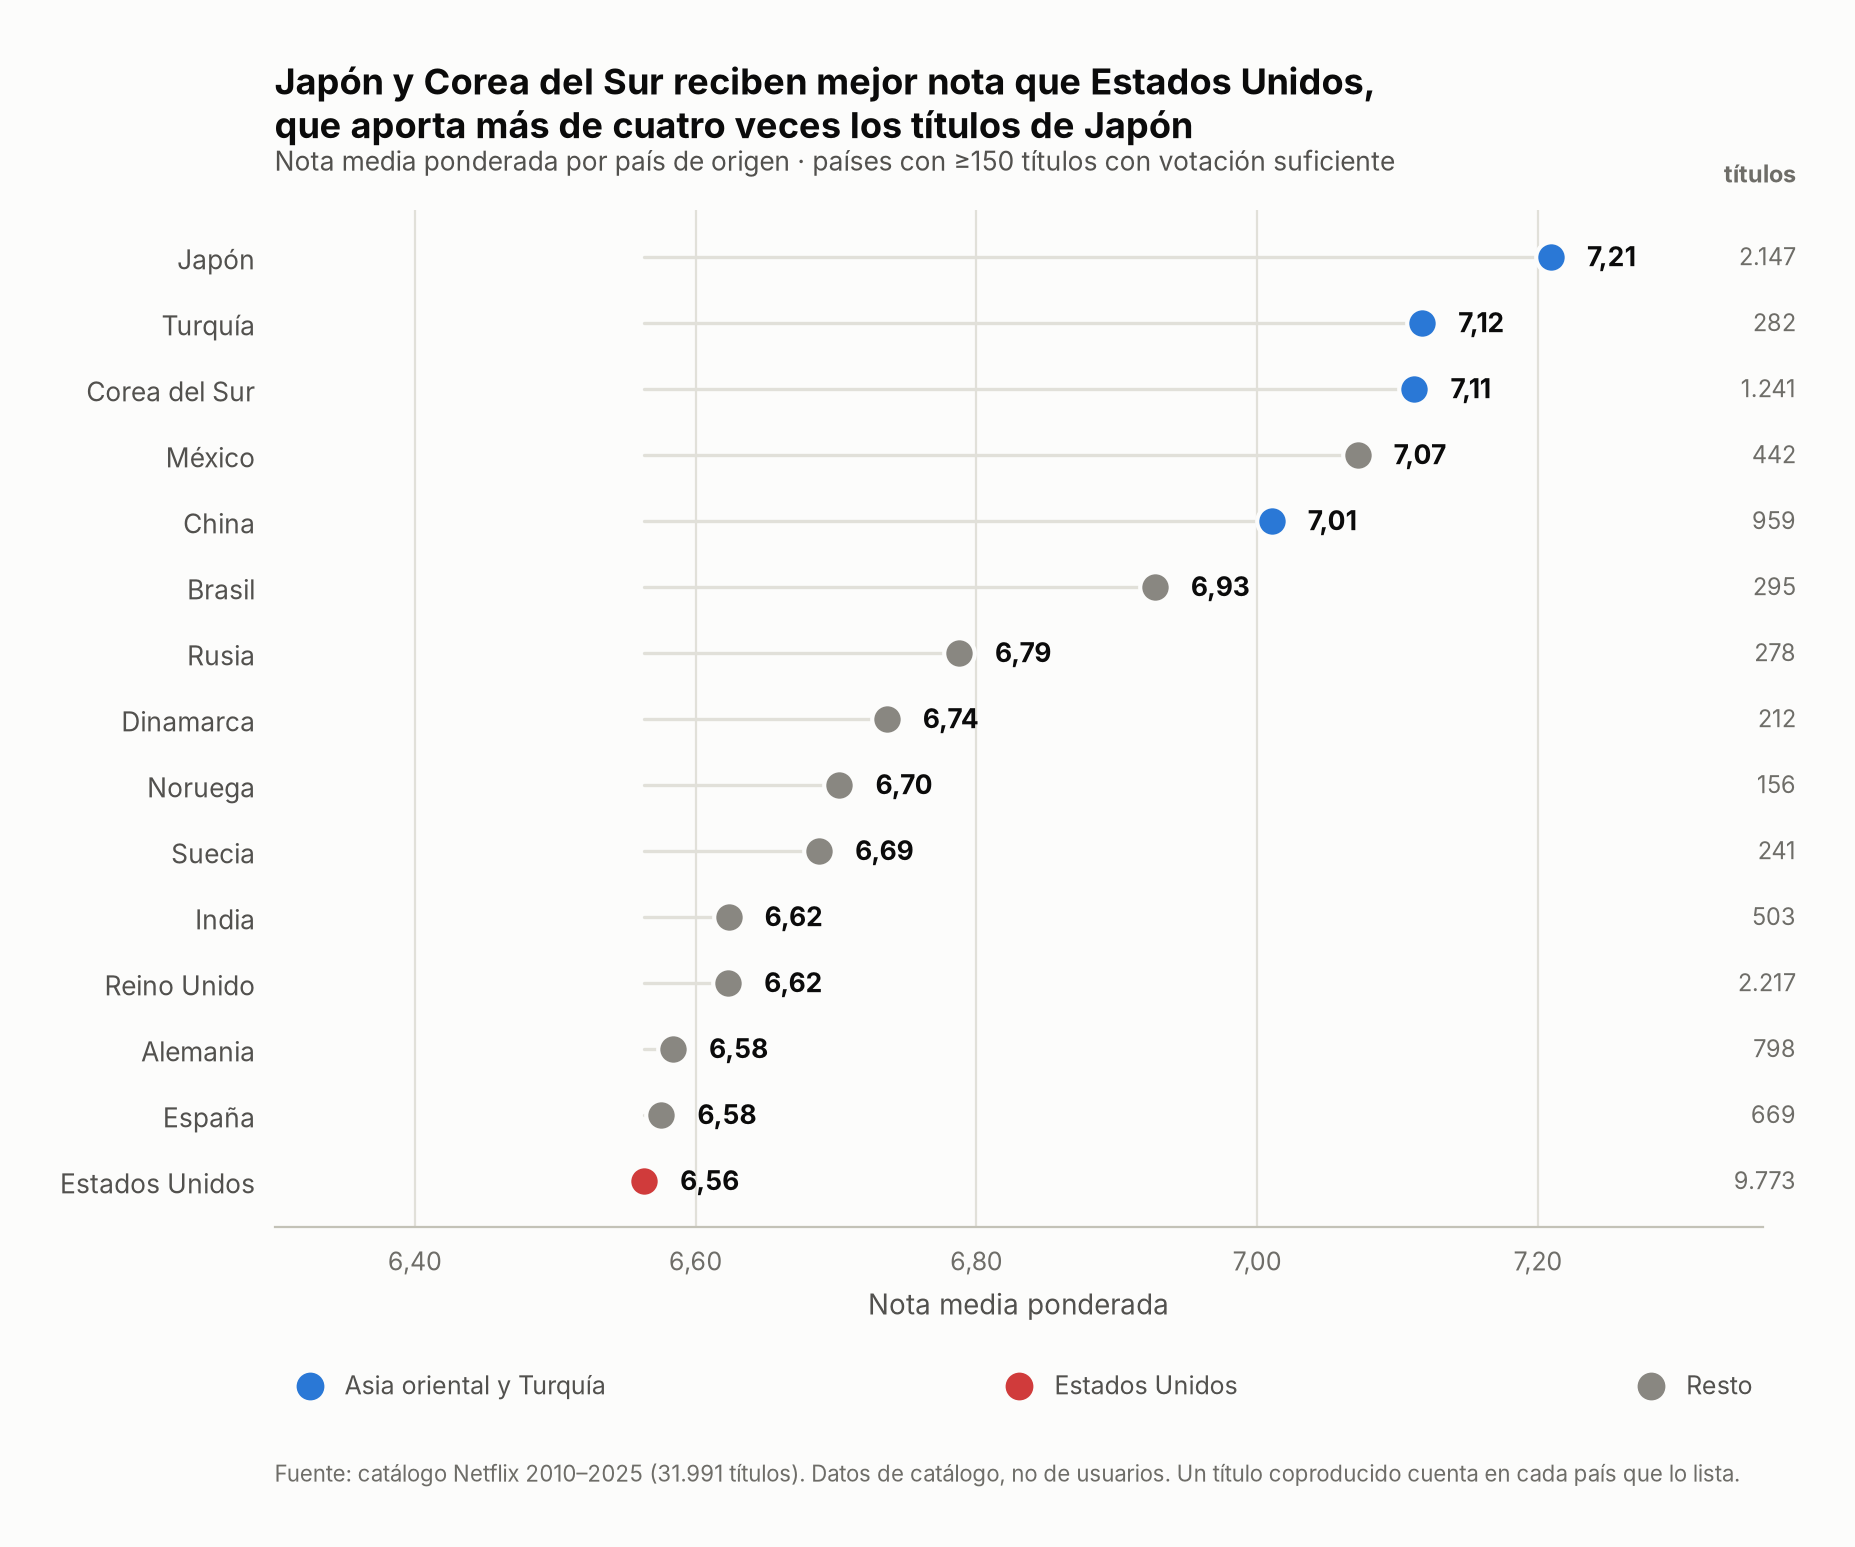

PosixPath('/home/user/Visualizaci-n_datos/images/exploratorio/17_paises_nota.png')

In [5]:
rp = desempeno_por_dimension(largos['pais'], cat, 'pais', minimo_titulos=150).head(15).sort_values('nota')
dest = {'Japan','South Korea','China','Turkey'}
fig, ax = plt.subplots(figsize=(9.6, 6.6))
col = [CATEGORICA[0] if p in dest else (ACENTO['sobreinvertido'] if p=='United States of America' else ACENTO['neutro']) for p in rp.index]
puntos_ordenados(ax, traducir(rp.index, PAISES), rp.nota, col, formato=n2,
                 etiqueta_derecha=[num_es(t) for t in rp.titulos], titulo_derecha='títulos')
ax.set_xlim(6.30, 7.36); ax.set_xlabel('Nota media ponderada'); eje_es(ax,'x',2); limpiar_ejes(ax,'x')
leyenda_segmentos(ax, {'Asia oriental y Turquía': CATEGORICA[0], 'Estados Unidos': ACENTO['sobreinvertido'],
                       'Resto': ACENTO['neutro']}, abajo=True, fontsize=9, altura=48)
titular(ax, 'Japón y Corea del Sur reciben mejor nota que Estados Unidos,\nque aporta más de cuatro veces los títulos de Japón',
        'Nota media ponderada por país de origen · países con ≥150 títulos con votación suficiente')
pie_de_fuente(ax, 'Un título coproducido cuenta en cada país que lo lista.', -84)
guardar(fig, '17_paises_nota')

## 18 · ¿Dónde el gasto se traduce en retorno?

Sobre las **3.540 películas** con `budget` y `revenue` positivos: el 22% del catálogo de películas. El subconjunto va declarado en el subtítulo del propio gráfico, no en una nota al pie que nadie lee.

Dos paneles con **la misma unidad y la misma escala**, para que la comparación sea visual y no aritmética. El panel derecho es el control: si el retorno subiera también con el presupuesto, la recomendación sería "gastar más" y no "apuntar a la nota".

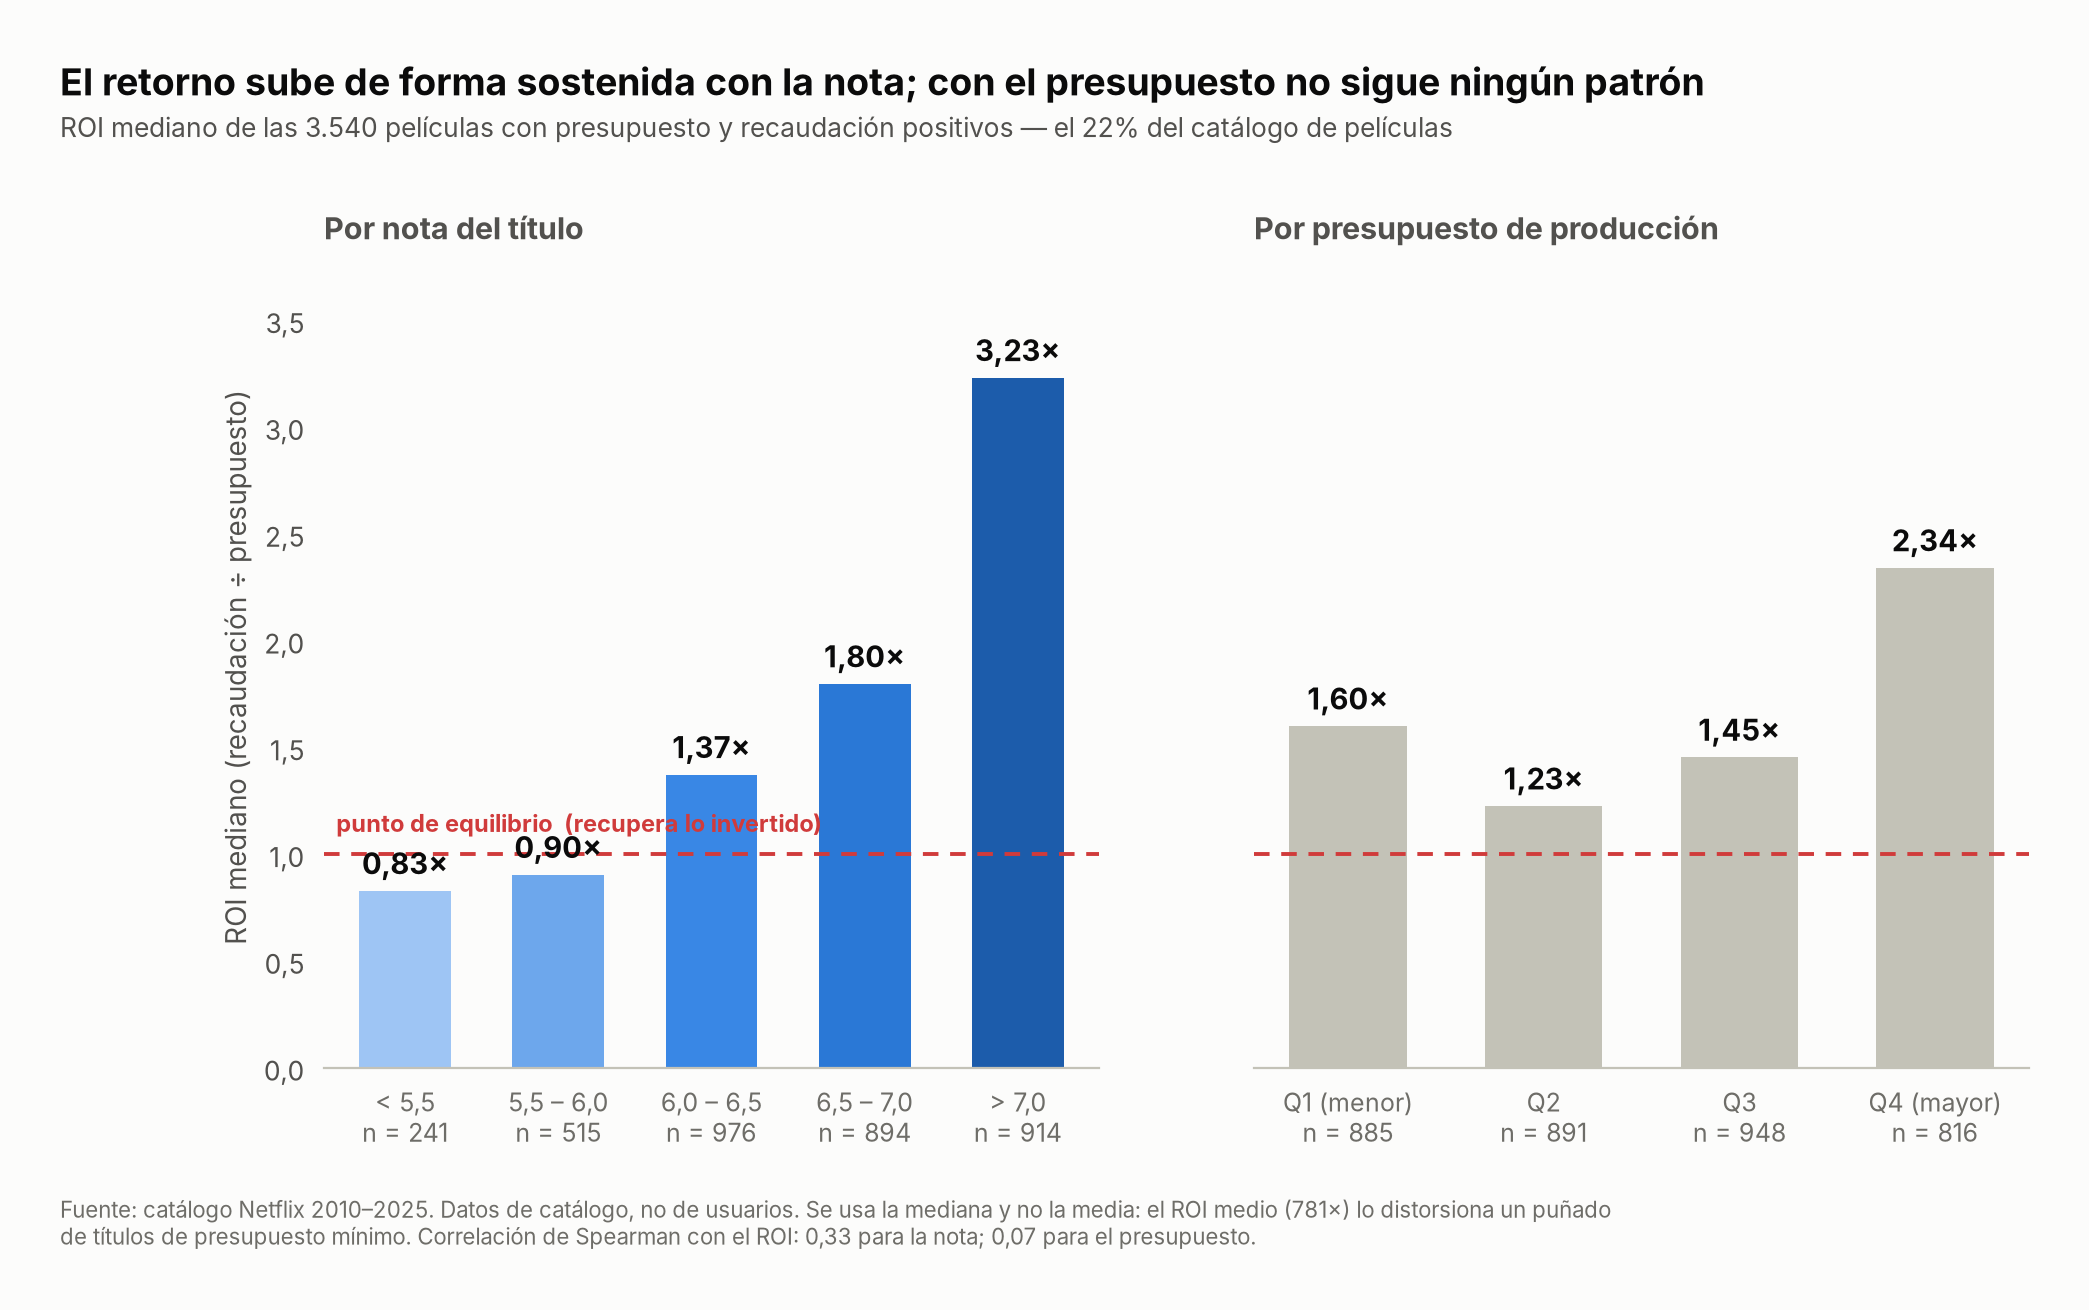

PosixPath('/home/user/Visualizaci-n_datos/images/exploratorio/18_roi_nota_presupuesto.png')

In [6]:
banda = roi_por_banda_de_nota(cat); cuartil = roi_por_cuartil_de_presupuesto(cat)
fig, axes = plt.subplots(1, 2, figsize=(11, 5.2), sharey=True)
for ax, datos, x, sub, col in (
    (axes[0], banda, 'banda', 'Por nota del título', [SECUENCIAL[i] for i in (1,2,3,4,5)]),
    (axes[1], cuartil, 'cuartil', 'Por presupuesto de producción', [GRIS_CONTEXTO]*4)):
    bars = ax.bar(datos[x].astype(str), datos.roi_mediano, color=col[:len(datos)], width=0.6)
    ax.axhline(1, color=ACENTO['sobreinvertido'], lw=1.4, ls=(0,(4,3)), zorder=1)
    for bb, v, n in zip(bars, datos.roi_mediano, datos.titulos):
        ax.annotate(f'{num_es(v,2)}×', xy=(bb.get_x()+bb.get_width()/2, v), xytext=(0,6),
                    textcoords='offset points', ha='center', fontsize=10.5, fontweight='bold', color=TINTA)
    # El n va bajo el eje y no dentro de la barra: en gris sobre el azul oscuro
    # quedaba ilegible, y la etiqueta de un gráfico nunca debe pelear con el dato.
    ax.set_xticks(range(len(datos)),
                  [f'{e}\nn = {num_es(v)}' for e, v in zip(datos[x].astype(str), datos.titulos)])
    ax.set_title(sub, loc='left', fontsize=11, pad=10, color=TINTA_SECUNDARIA)
    ax.grid(axis='y'); ax.grid(axis='x', visible=False); ax.set_ylim(0, 3.75)
    eje_es(ax,'y',1)
axes[0].set_ylabel('ROI mediano (recaudación ÷ presupuesto)')
# Sobre la línea y a la izquierda: las dos primeras barras quedan bajo el punto
# de equilibrio, así que ese es el único espacio realmente libre del gráfico.
axes[0].annotate('punto de equilibrio  (recupera lo invertido)', xy=(-0.45, 1),
                 xytext=(0, 6), textcoords='offset points', ha='left', va='bottom',
                 fontsize=8.5, color=ACENTO['sobreinvertido'], fontweight='bold')
fig.suptitle('El retorno sube de forma sostenida con la nota; con el presupuesto no sigue ningún patrón',
             x=0.005, ha='left', fontsize=13.5, fontweight='bold', y=1.08)
fig.text(0.005, 1.005, 'ROI mediano de las 3.540 películas con presupuesto y recaudación positivos — el 22% del catálogo de películas',
         ha='left', fontsize=9.5, color=TINTA_SECUNDARIA)
fig.text(0.005, -0.06, 'Fuente: catálogo Netflix 2010–2025. Datos de catálogo, no de usuarios. Se usa la mediana y no la media: el ROI medio (781×) lo distorsiona un puñado\nde títulos de presupuesto mínimo. Correlación de Spearman con el ROI: 0,33 para la nota; 0,07 para el presupuesto.',
         ha='left', fontsize=8, color=TINTA_TENUE)
guardar(fig, '18_roi_nota_presupuesto')

## 19 · ¿Dónde hay una oportunidad que hoy no se ve?

**Este es el hallazgo que sostiene la presentación.** Los dos primeros gráficos dicen qué se produce y qué se recibe bien; este los cruza y muestra que no coinciden.

Es una dispersión porque la pregunta es de *posición conjunta*: no "cuál género tiene más" ni "cuál tiene mejor nota", sino **qué géneros ocupan el cuadrante equivocado**. Las medianas parten el plano en cuatro y el color marca solo los dos cuadrantes accionables; el resto queda en gris de contexto.

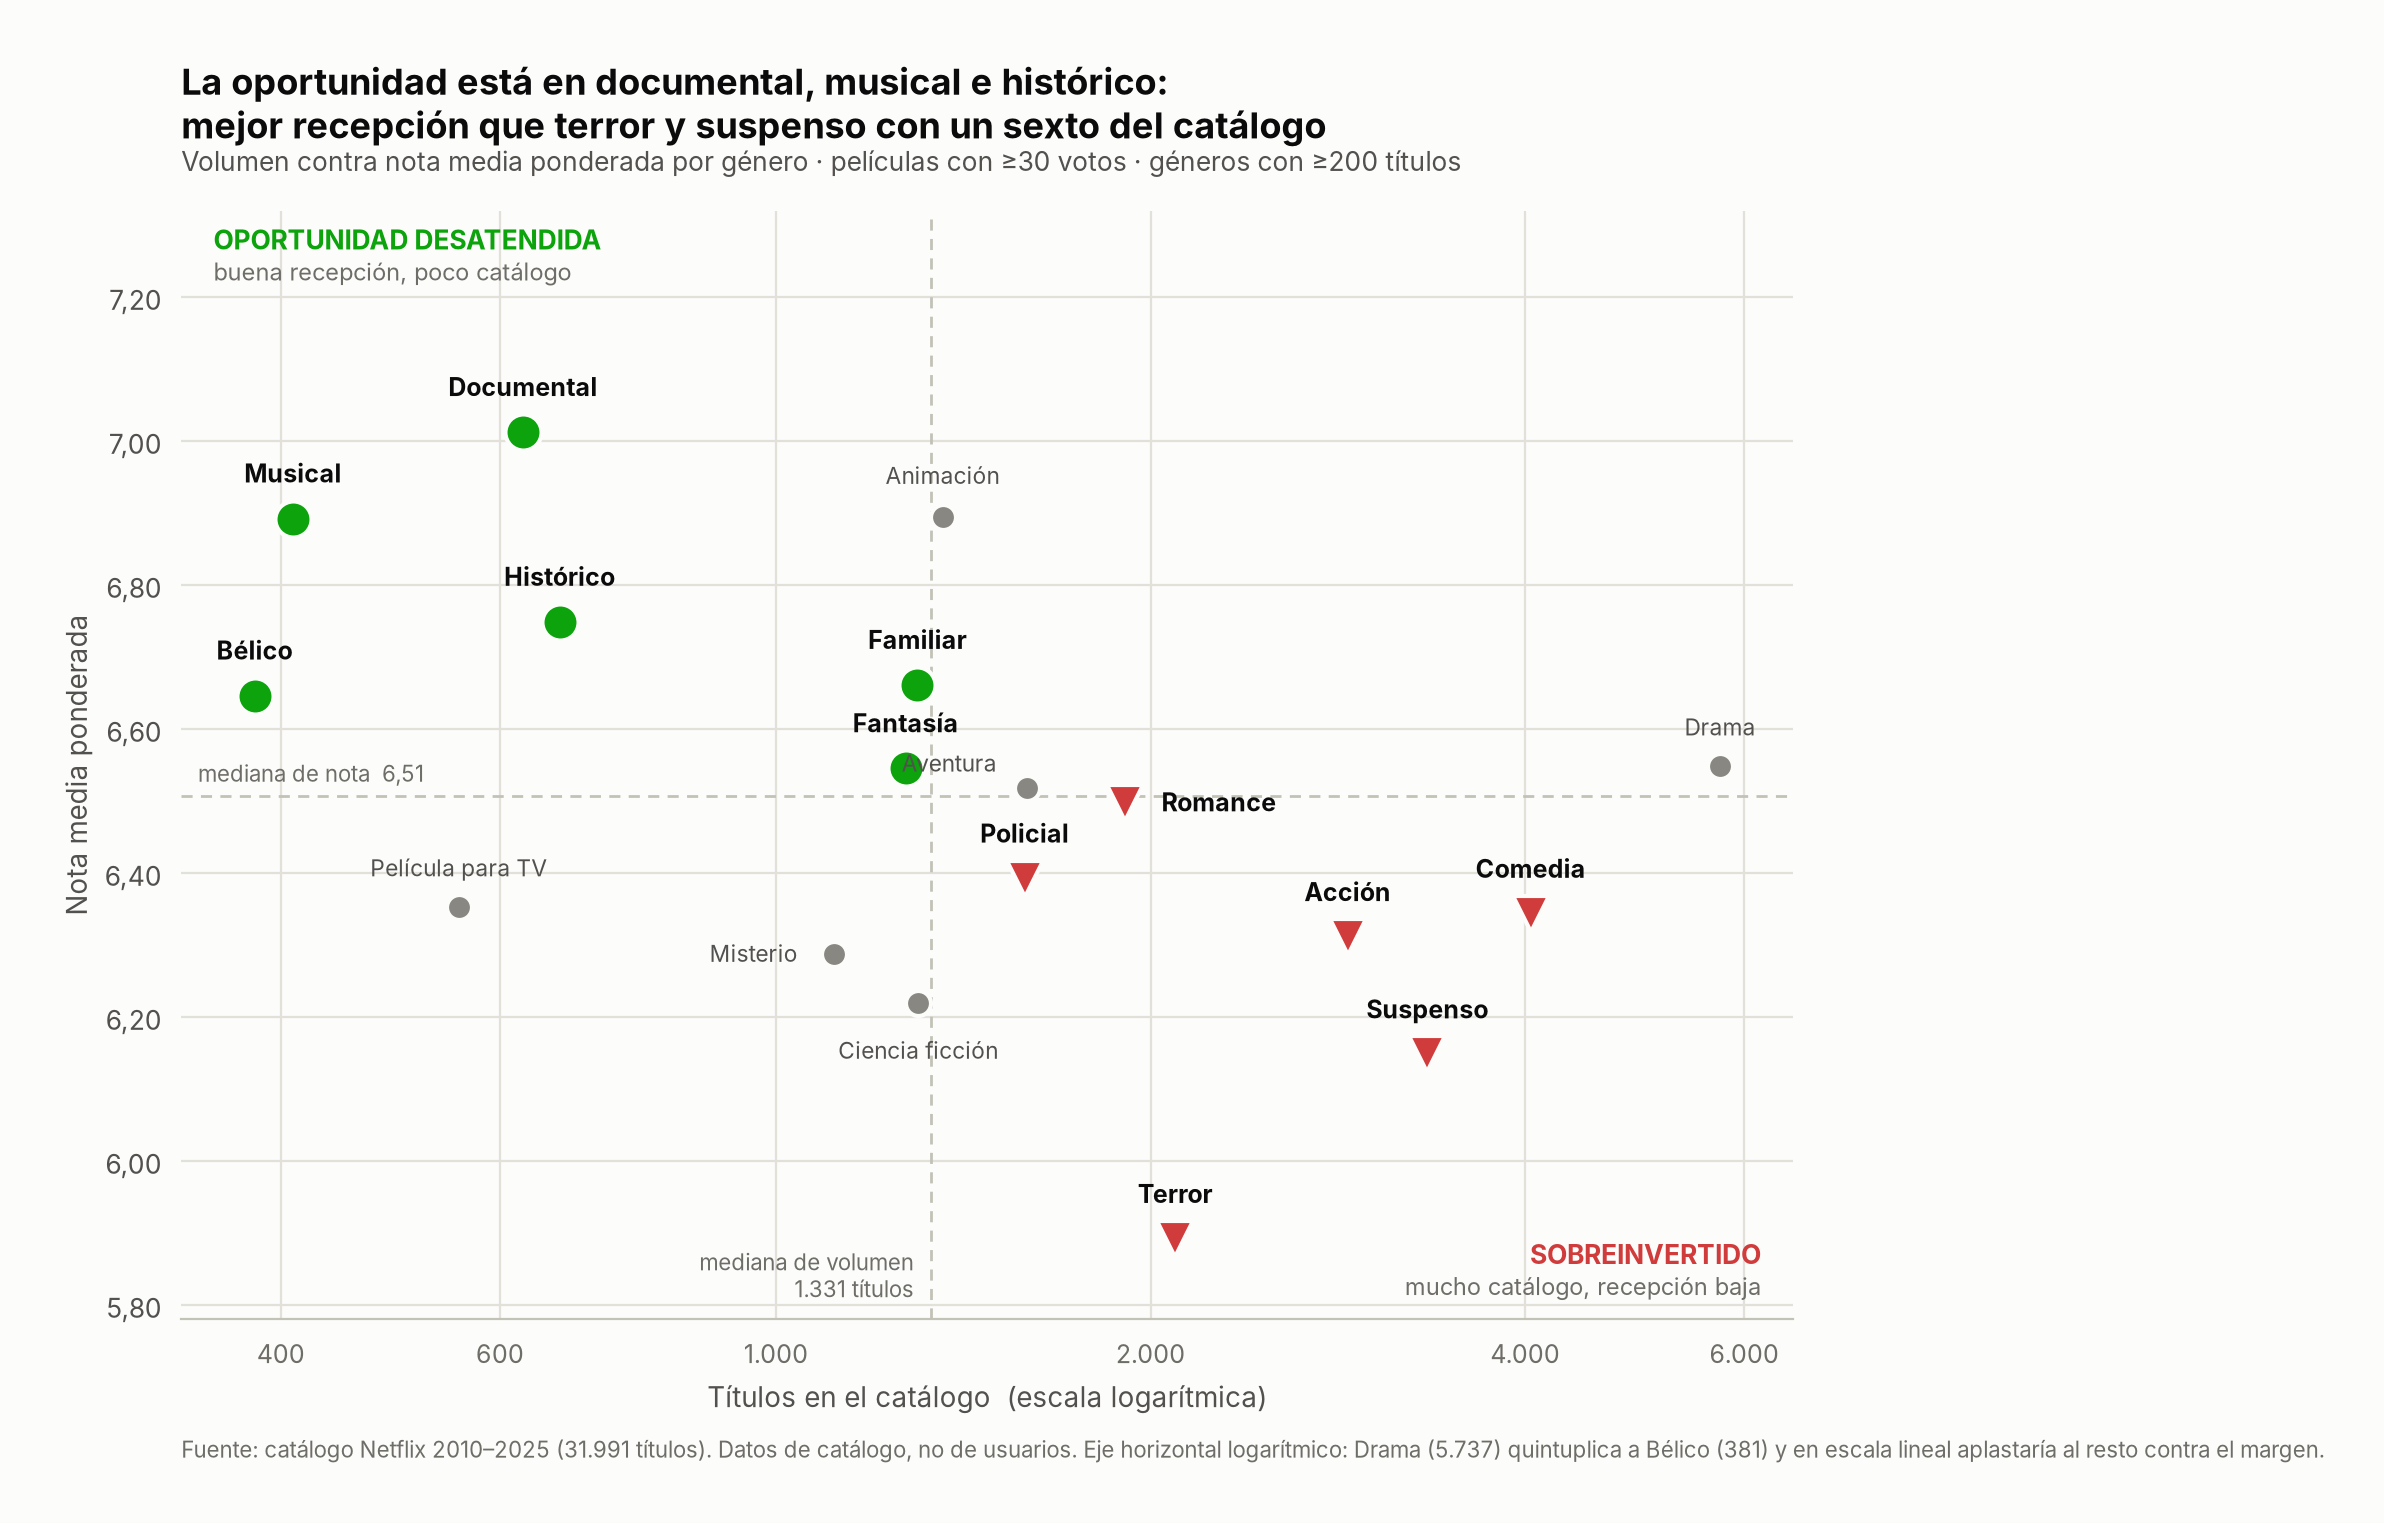

PosixPath('/home/user/Visualizaci-n_datos/images/exploratorio/19_brecha_oferta_recepcion.png')

In [7]:
fig, ax = plt.subplots(figsize=(10.4, 7.2))
cv, cn = res.attrs['corte_volumen'], res.attrs['corte_nota']
ax.axvline(cv, color=EJE, lw=1, ls=(0,(4,3))); ax.axhline(cn, color=EJE, lw=1, ls=(0,(4,3)))
ax.annotate('mediana de volumen\n1.331 títulos', xy=(cv,0), xycoords=('data','axes fraction'),
            xytext=(-6,8), textcoords='offset points', ha='right', fontsize=8, color=TINTA_TENUE)
ax.annotate('mediana de nota  6,51', xy=(0,cn), xycoords=('axes fraction','data'),
            xytext=(6,5), textcoords='offset points', fontsize=8, color=TINTA_TENUE)
ax.annotate('OPORTUNIDAD DESATENDIDA', xy=(0.02,0.965), xycoords='axes fraction', fontsize=9.5,
            fontweight='bold', color=ACENTO['oportunidad'])
ax.annotate('buena recepción, poco catálogo', xy=(0.02,0.937), xycoords='axes fraction', fontsize=8.5, color=TINTA_TENUE)
ax.annotate('SOBREINVERTIDO', xy=(0.98,0.05), xycoords='axes fraction', fontsize=9.5, ha='right',
            fontweight='bold', color=ACENTO['sobreinvertido'])
ax.annotate('mucho catálogo, recepción baja', xy=(0.98,0.022), xycoords='axes fraction', fontsize=8.5,
            ha='right', color=TINTA_TENUE)
for gen, fila in res.iterrows():
    c = ACENTO[fila.segmento] if fila.segmento in ('oportunidad','sobreinvertido') else ACENTO['neutro']
    destaca = fila.segmento in ('oportunidad','sobreinvertido')
    ax.plot(fila.titulos, fila.nota, MARCA[fila.segmento], color=c,
            markersize=13 if destaca else 9,
            markeredgecolor=FONDO, markeredgewidth=1.5, zorder=3 if destaca else 2)
    # Colocación manual solo donde el automático choca: el resto va encima del punto.
    desplaza = {'Adventure': ((-11, 6), 'right'), 'Mystery': ((-13, -3), 'right'),
                'Science Fiction': ((0, -20), 'center'), 'Animation': ((0, 12), 'center'),
                'Romance': ((13, -3), 'left')}
    offset, alineado = desplaza.get(gen, ((0, 13 if destaca else 11), 'center'))
    ax.annotate(GENEROS.get(gen, gen), xy=(fila.titulos, fila.nota), xytext=offset,
                textcoords='offset points', ha=alineado, fontsize=9 if destaca else 8.2,
                fontweight='bold' if destaca else 'normal', color=TINTA if destaca else TINTA_SECUNDARIA)
from matplotlib.ticker import NullFormatter, NullLocator
ax.set_xscale('log')
ax.xaxis.set_minor_locator(NullLocator()); ax.xaxis.set_minor_formatter(NullFormatter())
ax.set_xticks([400,600,1000,2000,4000,6000])
ax.set_xticklabels([num_es(v) for v in (400,600,1000,2000,4000,6000)])
ax.set_xlabel('Títulos en el catálogo  (escala logarítmica)')
ax.set_ylabel('Nota media ponderada'); eje_es(ax,'y',2)
ax.set_ylim(5.78, 7.32); ax.grid(True, which='major'); ax.grid(False, which='minor')
titular(ax, 'La oportunidad está en documental, musical e histórico:\nmejor recepción que terror y suspenso con un sexto del catálogo',
        'Volumen contra nota media ponderada por género · películas con ≥30 votos · géneros con ≥200 títulos')
pie_de_fuente(ax, 'Eje horizontal logarítmico: Drama (5.737) quintuplica a Bélico (381) y en escala lineal aplastaría al resto contra el margen.')
guardar(fig, '19_brecha_oferta_recepcion')

## 20 · ¿Conviene película o serie?

Gráfico de mancuerna (*dumbbell*): la pregunta es la **distancia** entre dos valores emparejados, y la mancuerna la codifica como longitud, que es lo que el ojo mide mejor. Dos barras agrupadas obligarían a comparar alturas y restar mentalmente.

Círculo para película y cuadrado para serie: la forma repite lo que dice el color, para que el gráfico siga siendo legible impreso en blanco y negro o para un lector con daltonismo.

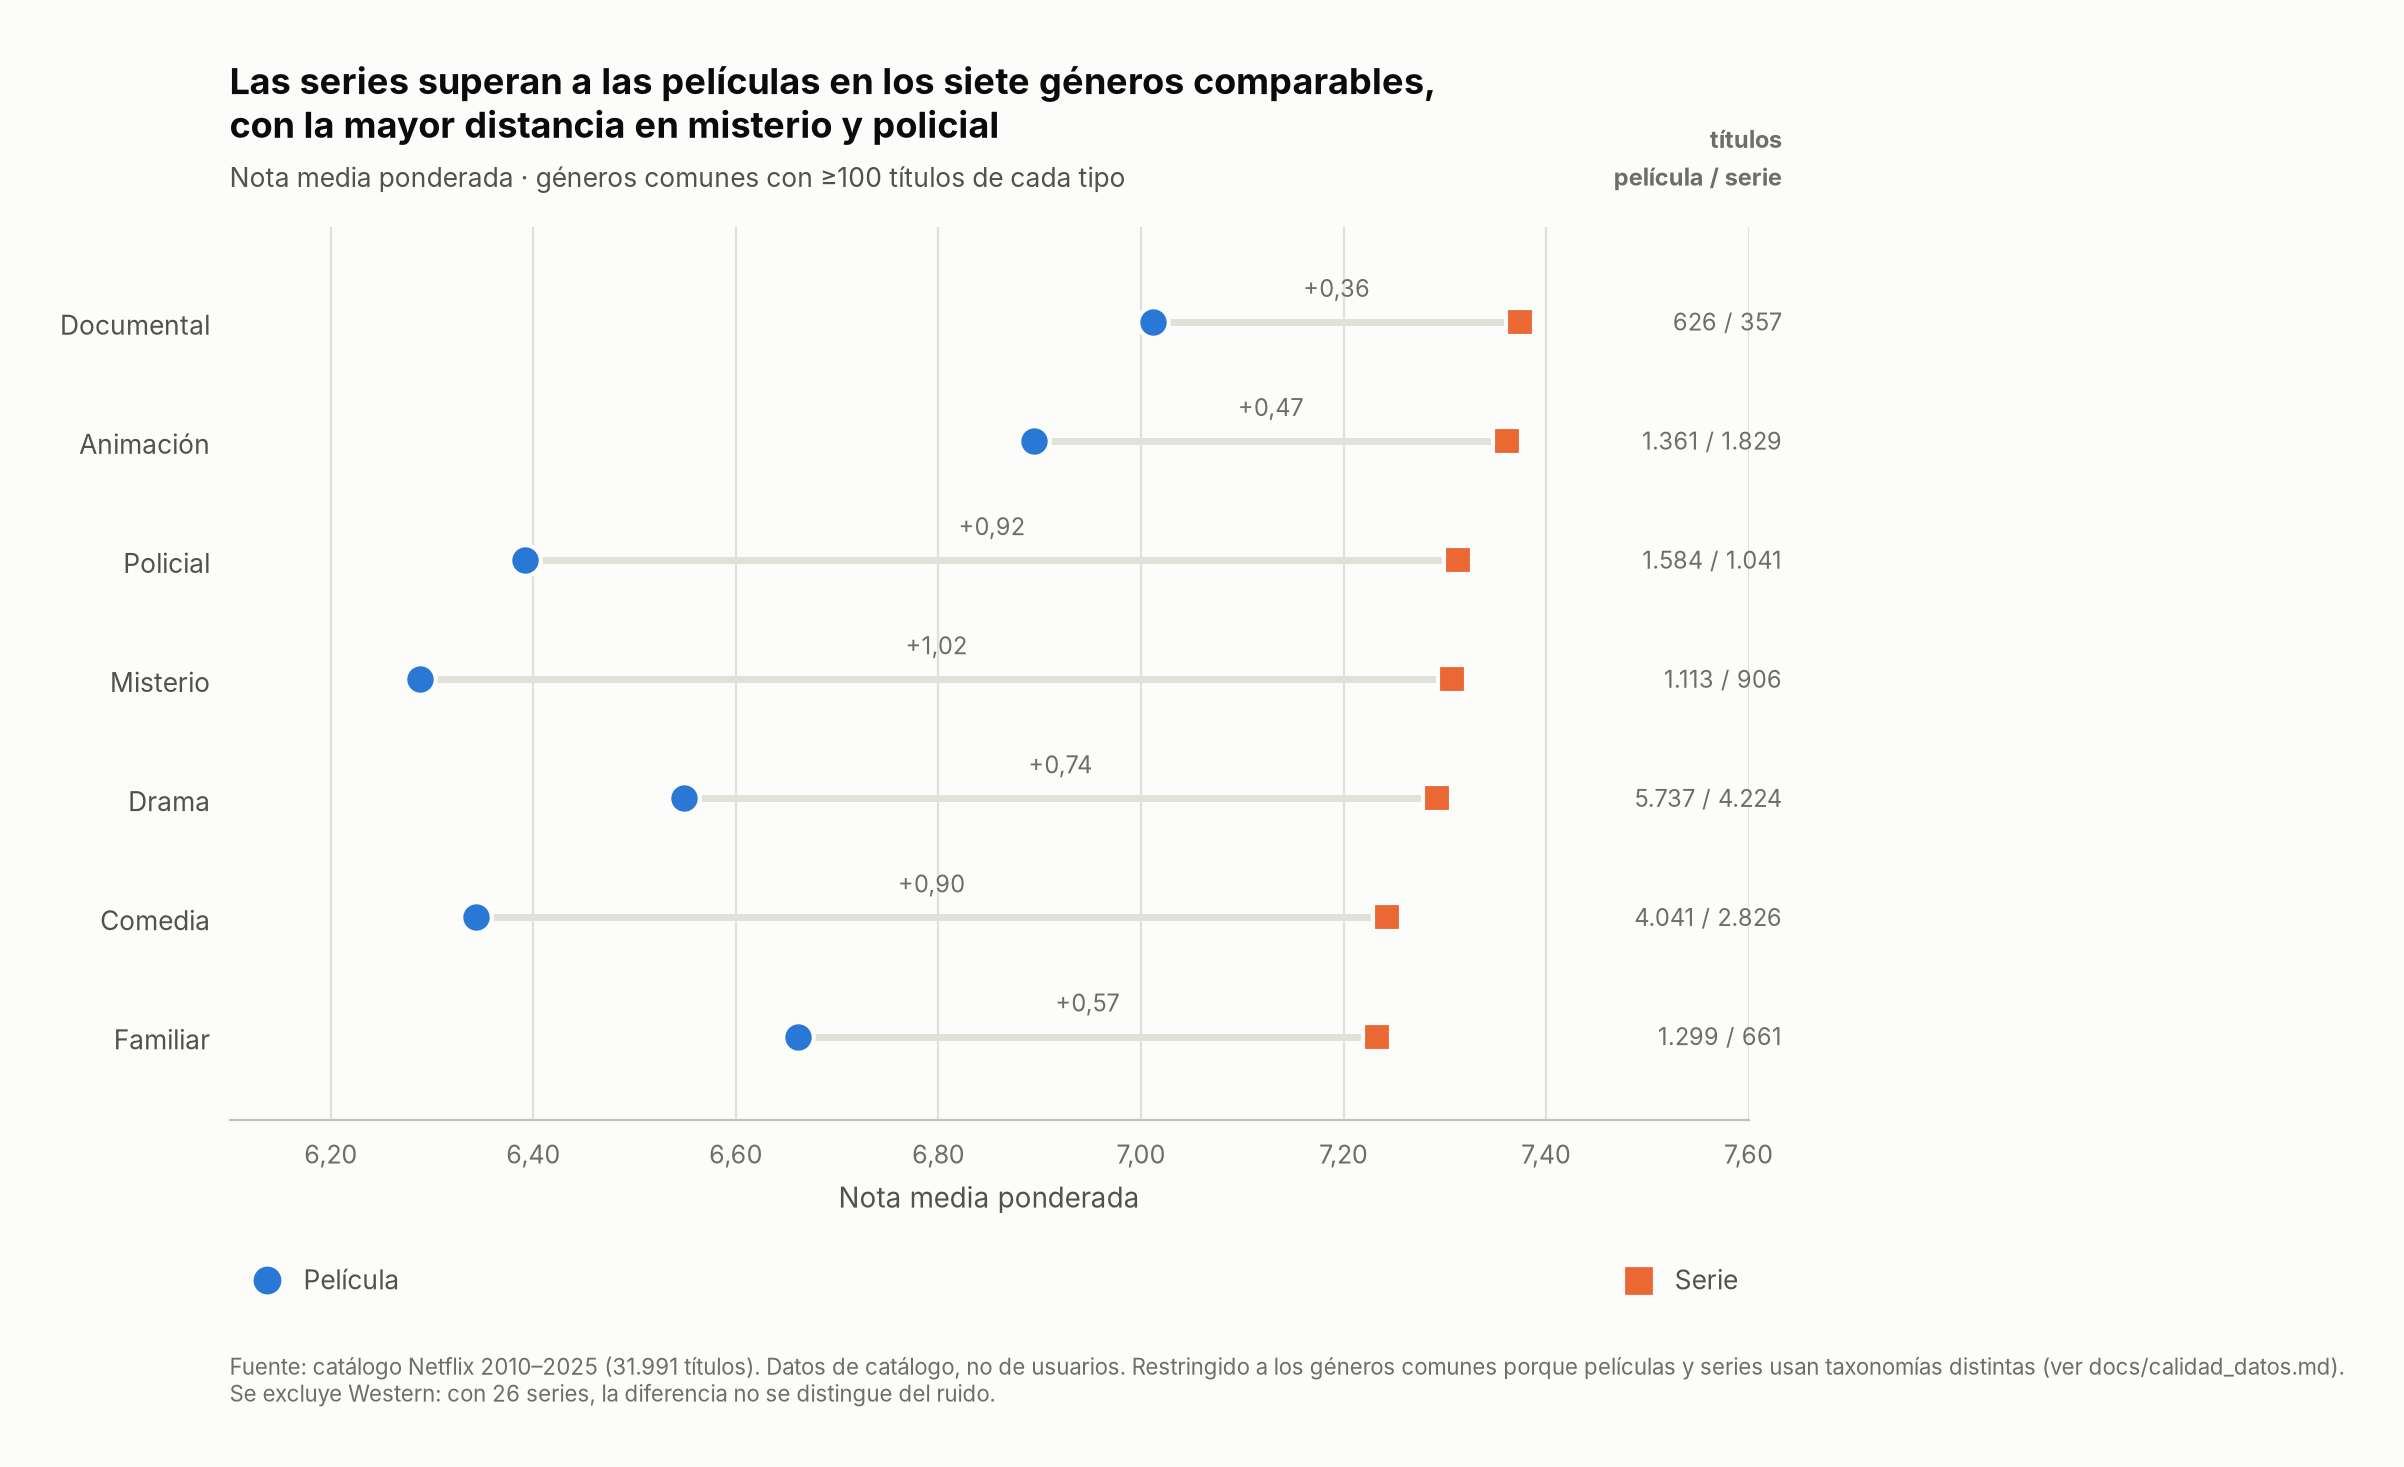

5 gráficos generados


In [8]:
comp = comparar_tipos_en_generos_comunes(largos['genero'], cat).sort_values('nota_Serie')
fig, ax = plt.subplots(figsize=(9.8, 5.8))
y = range(len(comp))
for i, (gen, fila) in enumerate(comp.iterrows()):
    ax.plot([fila['nota_Película'], fila['nota_Serie']], [i,i], color=GRILLA, lw=2.5, solid_capstyle='round', zorder=1)
    ax.annotate(f"+{num_es(fila['brecha'],2)}", xy=((fila['nota_Película']+fila['nota_Serie'])/2, i),
                xytext=(0,9), textcoords='offset points', ha='center', fontsize=8.5, color=TINTA_TENUE)
ax.plot(comp['nota_Película'], list(y), 'o', color=COLOR_TIPO['Película'], markersize=11,
        markeredgecolor=FONDO, markeredgewidth=1.5, zorder=3)
ax.plot(comp['nota_Serie'], list(y), 's', color=COLOR_TIPO['Serie'], markersize=10,
        markeredgecolor=FONDO, markeredgewidth=1.5, zorder=3)
ax.set_yticks(list(y), traducir(comp.index, GENEROS)); ax.set_ylim(-0.7, len(comp)-0.2)
ax.set_xlim(6.1, 7.6); ax.set_xlabel('Nota media ponderada'); eje_es(ax,'x',2); limpiar_ejes(ax,'x')
leyenda_segmentos(ax, {'Película': COLOR_TIPO['Película'], 'Serie': COLOR_TIPO['Serie']},
                  marcadores={'Película': 'o', 'Serie': 's'}, abajo=True, fontsize=9.5, altura=48)
for i, (gen, fila) in enumerate(comp.iterrows()):
    ax.annotate(f"{num_es(fila['titulos_Película'])} / {num_es(fila['titulos_Serie'])}",
                xy=(1, i), xycoords=('axes fraction','data'), xytext=(12,0),
                textcoords='offset points', ha='right', va='center', fontsize=8.5, color=TINTA_TENUE)
ax.annotate('títulos\npelícula / serie', xy=(1,1), xycoords='axes fraction', xytext=(12,10),
            textcoords='offset points', ha='right', va='bottom', fontsize=8.5,
            linespacing=1.4, fontweight='bold', color=TINTA_TENUE)
ax.set_title('')  # el título se escribe abajo con más aire para la cabecera derecha
titular(ax, 'Las series superan a las películas en los siete géneros comparables,\ncon la mayor distancia en misterio y policial',
        'Nota media ponderada · géneros comunes con ≥100 títulos de cada tipo', aire=6)
pie_de_fuente(ax, 'Restringido a los géneros comunes porque películas y series usan taxonomías distintas (ver docs/calidad_datos.md).\nSe excluye Western: con 26 series, la diferencia no se distingue del ruido.', -84)
guardar(fig, '20_peliculas_vs_series')
print('5 gráficos generados')

### Una advertencia honesta sobre este último gráfico

Las series ganan en los siete géneros, y la ventaja **sobrevive a un umbral común**: con `vote_count >= 30` para ambos tipos, las películas promedian 6,37 y las series 7,45; con `>= 100`, 6,46 contra 7,63. No es un artefacto del umbral por tipo ni de la fórmula del score ponderado — la brecha incluso crece al exigir más votos.

Pero la mediana de votos de una serie con votación suficiente es 32, contra 190 de una película. Quien vota una serie ya decidió invertir varias horas en ella; quien vota una película puede haberla abandonado a los veinte minutos. **Las dos notas no miden exactamente lo mismo**, y así hay que decirlo en la presentación. Es una limitación declarada, no un resultado que se esconde.

In [9]:
for umbral in (30, 100):
    sub = cat[cat['vote_count'] >= umbral]
    print(f'umbral común vote_count >= {umbral}:')
    print(sub.groupby('tipo')['vote_average'].agg(['mean', 'median', 'size']).round(2).to_string())
    print()

print('mediana de votos por tipo (títulos con votación suficiente):')
print(cat[cat['votos_suficientes']].groupby('tipo')['vote_count'].median().to_string())

umbral común vote_count >= 30:
          mean  median   size
tipo                         
Película  6.37     6.4  13217
Serie     7.45     7.5   4005

umbral común vote_count >= 100:
          mean  median  size
tipo                        
Película  6.46     6.5  9528
Serie     7.63     7.7  2277

mediana de votos por tipo (títulos con votación suficiente):
tipo
Película    190.0
Serie        32.0


## 21 · ¿Y cuáles de esos géneros además devuelven la plata?

El gráfico 19 cruza **volumen contra nota** y encuentra la oportunidad de catálogo. Pero una oportunidad de recepción no es automáticamente una oportunidad financiera, y conviene comprobarlo antes de recomendar nada.

Al cruzar **nota contra ROI** aparecen dos cosas que corrigen la lectura ingenua del gráfico 19:

1. **Terror tiene el presupuesto mediano más bajo del catálogo: 7 millones de dólares**, contra 50 de animación o 60 de aventura. Su ROI mediano es 2,03×, sobre la mediana. Su volumen no es un error: es una apuesta deliberada de costo. La nota baja es el precio de esa apuesta, no un descuido.
2. **Histórico y bélico tienen las mejores notas entre las películas con datos financieros (6,92 y 6,85) y los peores retornos (1,16× y 1,27×).** Recomendarlos solo por su nota sería recomendar prestigio, no negocio — y hay que decirlo con esa palabra.

El cruce que sí sostiene una recomendación de inversión es el cuadrante superior derecho: **animación, familiar, aventura y musical**, buenos en las dos dimensiones a la vez.

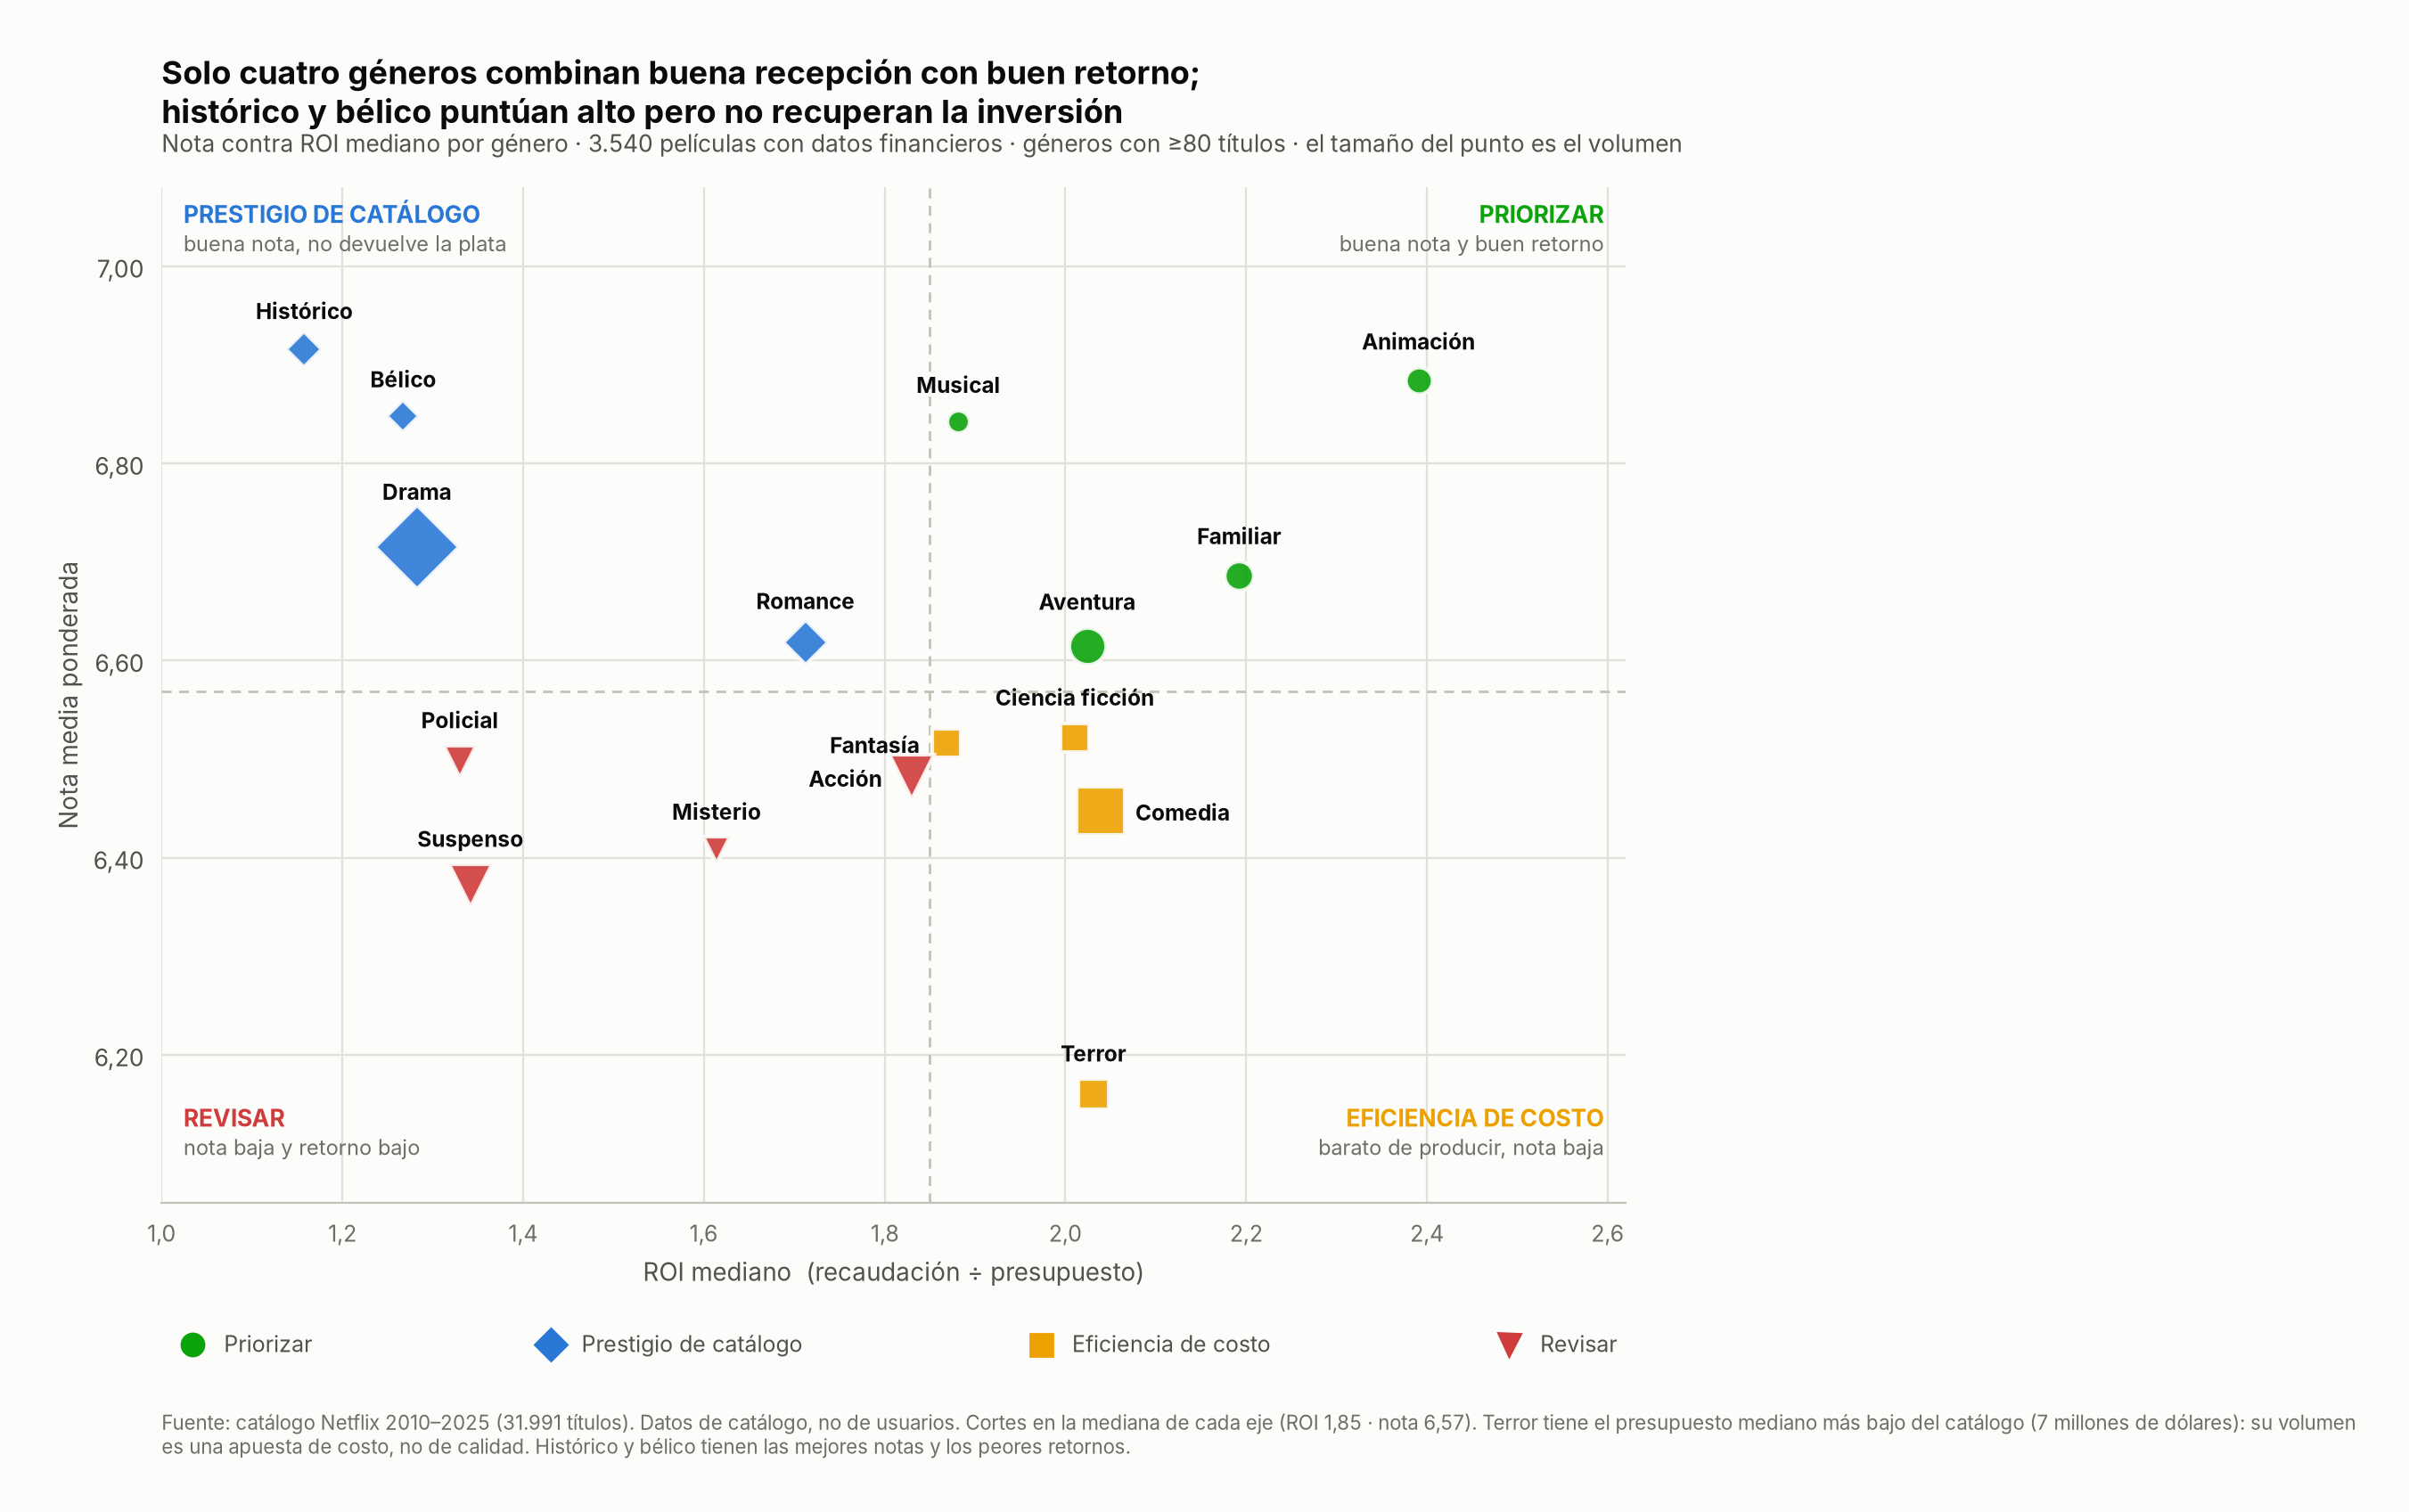

gráfico 21 generado


In [10]:
rr = retorno_y_nota_por_genero(largos['genero'], cat)
COLOR_SEG = {'priorizar': ACENTO['oportunidad'], 'prestigio': CATEGORICA[0],
             'eficiencia': CATEGORICA[3], 'revisar': ACENTO['sobreinvertido']}
fig, ax = plt.subplots(figsize=(10.6, 7.4))
cr, cn = rr.attrs['corte_roi'], rr.attrs['corte_nota']
ax.axvline(cr, color=EJE, lw=1, ls=(0,(4,3))); ax.axhline(cn, color=EJE, lw=1, ls=(0,(4,3)))
# El eje X es el ROI: nota alta + ROI alto cae ARRIBA A LA DERECHA, y nota alta
# con ROI bajo (prestigio) arriba a la izquierda.
cuadrantes = [
    (0.015, 0.965, 'PRESTIGIO DE CATÁLOGO', 'buena nota, no devuelve la plata', 'left', COLOR_SEG['prestigio']),
    (0.985, 0.965, 'PRIORIZAR', 'buena nota y buen retorno', 'right', COLOR_SEG['priorizar']),
    (0.015, 0.075, 'REVISAR', 'nota baja y retorno bajo', 'left', COLOR_SEG['revisar']),
    (0.985, 0.075, 'EFICIENCIA DE COSTO', 'barato de producir, nota baja', 'right', COLOR_SEG['eficiencia'])]
for x, y, titulo, sub, ha, color in cuadrantes:
    ax.annotate(titulo, xy=(x, y), xycoords='axes fraction', ha=ha, fontsize=9.5,
                fontweight='bold', color=color)
    ax.annotate(sub, xy=(x, y - 0.028), xycoords='axes fraction', ha=ha, fontsize=8.5, color=TINTA_TENUE)
for gen, fila in rr.iterrows():
    color = COLOR_SEG[fila.segmento]
    tam = 8 + (fila.titulos / rr.titulos.max()) * 16
    ax.plot(fila.roi, fila.nota, MARCA[fila.segmento], color=color, markersize=tam,
            alpha=0.9, markeredgecolor=FONDO, markeredgewidth=1.5, zorder=3)
    desplaza = {'Fantasy': ((-11, -4), 'right'), 'Action': ((-12, -4), 'right'),
                'Comedy': ((14, -4), 'left'), 'Science Fiction': ((0, tam / 2 + 7), 'center')}
    offset, alineado = desplaza.get(gen, ((0, tam / 2 + 7), 'center'))
    ax.annotate(GENEROS.get(gen, gen), xy=(fila.roi, fila.nota), xytext=offset,
                textcoords='offset points', ha=alineado,
                fontsize=8.8, fontweight='bold', color=TINTA)
ax.set_xlabel('ROI mediano  (recaudación ÷ presupuesto)')
ax.set_ylabel('Nota media ponderada')
eje_es(ax, 'x', 1); eje_es(ax, 'y', 2)
ax.set_xlim(1.0, 2.62); ax.set_ylim(6.05, 7.08)
ax.grid(True)
leyenda_segmentos(ax, {'Priorizar': COLOR_SEG['priorizar'], 'Prestigio de catálogo': COLOR_SEG['prestigio'],
                       'Eficiencia de costo': COLOR_SEG['eficiencia'], 'Revisar': COLOR_SEG['revisar']},
                  marcadores={'Priorizar': MARCA['priorizar'], 'Prestigio de catálogo': MARCA['prestigio'],
                              'Eficiencia de costo': MARCA['eficiencia'], 'Revisar': MARCA['revisar']},
                  abajo=True, fontsize=9, altura=48)
titular(ax, 'Solo cuatro géneros combinan buena recepción con buen retorno;\nhistórico y bélico puntúan alto pero no recuperan la inversión',
        'Nota contra ROI mediano por género · 3.540 películas con datos financieros · géneros con ≥80 títulos · el tamaño del punto es el volumen')
pie_de_fuente(ax, 'Cortes en la mediana de cada eje (ROI 1,85 · nota 6,57). Terror tiene el presupuesto mediano más bajo del catálogo (7 millones de dólares): su volumen\nes una apuesta de costo, no de calidad. Histórico y bélico tienen las mejores notas y los peores retornos.', -84)
guardar(fig, '21_recepcion_vs_retorno')
print('gráfico 21 generado')

---
## Tarea 21 — revisión de coherencia (IE9)

Regla: si un visual no responde una pregunta del Gerente de Contenidos, se elimina por bonito que esté.

| Visual | Pregunta que responde | ¿Se mantiene? |
|---|---|---|
| 16 · Género | Qué géneros priorizar | Sí |
| 17 · País | Qué mercados priorizar | Sí |
| 18 · ROI | Dónde el gasto se convierte en retorno | Sí |
| 19 · Brecha | Dónde hay oportunidad desatendida | Sí — abre la recomendación |
| 21 · Recepción vs retorno | Cuál de esas oportunidades además paga | Sí — es el que la cierra |
| 20 · Tipo | Película o serie | Sí |

**Descartados antes de dibujarlos**, y esto también es evidencia de selección correcta (IE7):

- *Evolución del catálogo por año* — saldría plano por construcción: 1.000 títulos exactos por año.
- *Duración contra popularidad* — `duration` no tiene varianza.
- *Desempeño por clasificación etaria* — la columna no existe en el dataset.
- *Top de directores* — 68,5% de nulos en series; solo sería válido en películas y no responde ninguna de las cinco preguntas.
- *Mapa coroplético por país* — el dato es "país que aparece en la ficha", no volumen de producción ni de consumo. Un mapa sugiere cobertura geográfica y haría leer más de lo que el dato dice; el dot plot ordenado responde lo mismo sin esa insinuación.
- *Torta de participación por género* — con 18 géneros, una torta es ilegible, y la pregunta ("cuáles priorizar") es de orden, no de parte-todo.

In [11]:
frase('Lo que más se produce no es lo que mejor se recibe, y [la nota predice el retorno] mejor que el presupuesto.')

In [12]:
nota('Estos seis gráficos son la evidencia. El **notebook 04** los ordena como una historia para presentarla: es el informe que se muestra '
     'en la defensa, y de ahí se pasa al dashboard.', 'Siguiente paso', 'verde')